# Calculation general CME distributions in $\beta$

\begin{equation}
    \rho_\beta(\beta) = \frac{1}{N} \int_{[0,\pi] \times [0,2\pi]}\sin\theta d\theta d\phi  \rho (\alpha(\theta, \phi)) \int \sin\theta' d\theta' \int d\phi' \rho^{CME}(\theta') \delta(\beta -\arccos ( \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta))
\end{equation}

In [1]:
import numpy as np
import scipy
import scipy.special as sc
import matplotlib.pyplot as plt


In [2]:
# general distribution of active regions per unit area 
def rice_dist(x, sigma, nu):
    x = np.abs(x)
    return x / sigma**2 * np.exp( - (x**2 + nu **2 ) / (2 * sigma **2)) * sc.iv(0, (x * nu / sigma**2))

sigma_fit, nu_fit = (9.02769086 / 180 * np.pi, 10.48768514 / 180 * np.pi)

def rho(alpha, err=0.001):
    return rice_dist(np.pi / 2 - alpha, sigma_fit, nu_fit) / 2 / np.pi / (np.sin(alpha) + err) / 2 
            # fit of dist when integrated over phi and absolute value so accounting for that

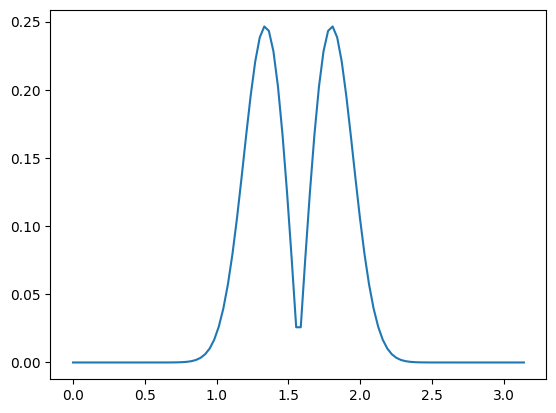

In [3]:
alpha = np.linspace(0, np.pi, 100)
plt.plot(alpha, rho(alpha))

In [4]:
f = lambda x: rice_dist(x, sigma_fit, nu_fit)

from scipy.integrate import quad

quad(f,0, np.pi)

(1.0, 2.535040833501201e-09)

Before for flare distribution we had
$$
\cos \alpha = \sin \tau \sin \theta \cos \phi +\cos \theta \cos \tau  $$
and $\mu = \cos \theta$

Now we have $\beta \sim \alpha, \theta \sim \tau, \theta'\sim \theta$ and $ \phi'\sim \phi$ so  
$$
\cos \beta = \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta  $$

The distribution for CME angle, properly normalized!

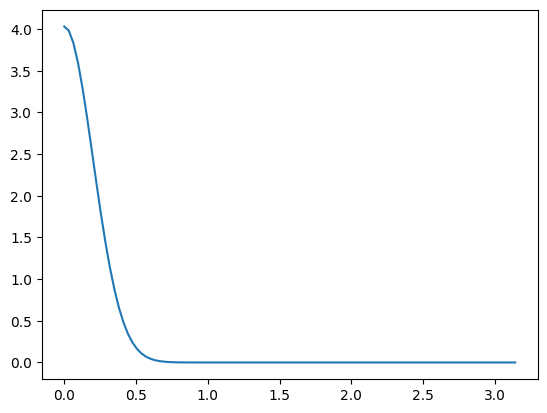

In [5]:
from scipy.stats import norm
# normalization, later to be determined
N = 1

def rho_CME(theta2, loc=0, scale = 0.2):
    return norm.pdf(theta2, loc, scale) /N

f = lambda theta2 : rho_CME(theta2) * np.sin(theta2) * 2 * np.pi


N = quad(f, 0, np.pi/2)[0]

T = np.linspace(0, np.pi, 100)
plt.plot(T, rho_CME(T))



In [6]:
def cot(theta):
    return 1 / np.tan(theta)

# general distribution for given tau
def get_sinphi2(theta, phi, theta2, beta):
    cosphi2 = np.cos(beta) / (np.sin(theta)*np.sin(theta2)) - cot(theta)*cot(theta2)
    return 0 if np.abs(cosphi2) >1 else (1-cosphi2**2)**0.5

def get_alpha(tau, theta, phi):
    return np.arccos( np.sin( tau ) * np.sin(theta) * np.cos(phi) + np.cos(tau) * np.cos(theta))



def f_integrand_(beta, tau, vec=True):
    if vec:
        def integrand_vec(x):
            theta = x[0]
            phi = x[1]
            theta2 = x[2]
            return integrand(theta, phi, theta2, beta, tau)
        return integrand_vec
    else:
        def integrand2(theta, phi, theta2):
            return integrand(theta, phi, theta2, beta, tau)
        return integrand2

def integrand(theta, phi, theta2, beta, tau):
    sinphi2 = get_sinphi2(theta, phi, theta2, beta)
    alpha = get_alpha(tau, theta, phi)
        
    return np.sin(theta)**2 * rho(alpha) * np.sin(theta2)**2 * rho_CME(theta2) * sinphi2 / np.abs(np.sin(beta))


If all integrations can be done at once this will save much time!
\begin{equation}
    \rho_\beta(\beta) = \frac{1}{N} \int_{[0,\pi] \times [0,2\pi]}\sin\theta d\theta d\phi  \rho (\alpha(\theta, \phi)) \int \sin\theta' d\theta' \int d\phi' \rho^{CME}(\theta') \delta(\beta -\arccos ( \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta))
\end{equation}

\begin{equation}
    \rho_\beta(\beta) = \frac{1}{N} \int_{[0,\pi] \times [0,2\pi] \times [0,\pi] \times [0,2\pi ]}d\theta d\phi d\theta' d\phi' \sin\theta   
    \rho (\alpha(\theta, \phi)) \sin\theta'  \rho^{CME}(\theta') \delta(\beta -\arccos ( \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta))
\end{equation}

so we use $\cos \beta = \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta$, or equivalently that
$$\cos \phi' = \frac{\cos\beta - \cos\theta'\cos\theta}{\sin \theta'\sin\theta}$$ 
to find that 


\begin{equation}
    \int d\phi'   \delta(\beta -\arccos ( \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta)) = \frac{\sin\theta\sin\theta'\sin\phi'(\theta, \theta',\beta)}{|\sin\beta|}
\end{equation}
since $\int dx \delta(f(x)) = \int dy (f'(x))^{-1} \delta(y) = 1/f'(x_0)$ where $y=f(x)$ and  $x_0$ such that $y=f(x_0)=0$.

Therefore 
\begin{equation}
    \rho_\beta(\beta) = \frac{1}{N} \int_{[0,\pi] \times [0,2\pi] \times [0,\pi] }d\theta d\phi d\theta'  \sin\theta   
    \rho (\alpha(\theta, \phi)) \sin\theta'  \rho^{CME}(\theta')  \frac{\sin\theta\sin\theta'\sin\phi'(\theta, \theta',\beta)}{|\sin\beta|}
\end{equation}

\begin{equation}
    \rho_\beta(\beta) = \frac{1}{N} \int_{[0,\pi] \times [0,2\pi] \times [0,\pi] }d\theta d\phi d\theta'   
    \rho (\alpha(\theta, \phi))   \rho^{CME}(\theta')  \frac{\sin^2\theta\sin^2\theta'\sin\phi'(\theta, \theta',\beta)}{|\sin\beta|}
\end{equation}




This calculation will take a while.

or different approach might be faster? $\phi'$ taken to be a function? 


In [13]:
###
# fast is keyword for fast monte-carlo simulation vs thorough numerical integration
# fast = True is monte-carlo using package mcint
# fast = False is using scipy.integrade.nquad
fast = False

In [14]:
betas = np.linspace(0.01, np.pi / 2 - 0.01, 20)
betas

array([0.01      , 0.09162086, 0.17324172, 0.25486258, 0.33648344,
       0.4181043 , 0.49972516, 0.58134602, 0.66296687, 0.74458773,
       0.82620859, 0.90782945, 0.98945031, 1.07107117, 1.15269203,
       1.23431289, 1.31593375, 1.39755461, 1.47917547, 1.56079633])

Computing Betas: 100%|███████████████████████████| 5/5 [00:00<00:00, 1945.41it/s]
/usr/local/lib/python3.11/site-packages/scipy/integrate/_quadpack_py.py:1233: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,
/usr/local/lib/python3.11/site-packages/scipy/integrate/_quadpack_py.py:1233: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,
/usr/local/lib/python3.11/site-packages/scipy/integrate/_quadpack_py.py:1233: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  o

For params beta=1.315933748879913, tau = 0.7853981633974483 we find the distribution to be 0.010284656171882579, with estimated error 1.9061934653674673e-05. Taking 1900.66 seconds to calculate.
For params beta=1.5607963267948965, tau = 0.7853981633974483 we find the distribution to be 0.009999991061278982, with estimated error 9.9999092520414e-06. Taking 2404.03 seconds to calculate.
For params beta=1.3975546081849075, tau = 0.7853981633974483 we find the distribution to be 0.010167954136624796, with estimated error 9.99978566525558e-06. Taking 12919.35 seconds to calculate.


/usr/local/lib/python3.11/site-packages/scipy/integrate/_quadpack_py.py:1233: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,
/usr/local/lib/python3.11/site-packages/scipy/integrate/_quadpack_py.py:1233: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probab

For params beta=1.2343128895749185, tau = 0.7853981633974483 we find the distribution to be 0.010176742645202562, with estimated error 2.859625399930321e-05. Taking 19745.85 seconds to calculate.
[4.909303815842216e-11, 0.00113404043786093, 0.002098566427120833, 0.003001919941460483, 0.0038636277938305, 0.004698260108988724, 0.00553566346811016, 0.0063011911664989685, 0.006980198499961342, 0.007444495009302519, 0.007694623124679994, 0.007762869602409423, 0.007623055211972881, 0.007524749736248599, 0.00736382419209615, 0.010176742645202562, 0.010284656171882579, 0.010167954136624796, 0.010004885601973884, 0.009999991061278982]


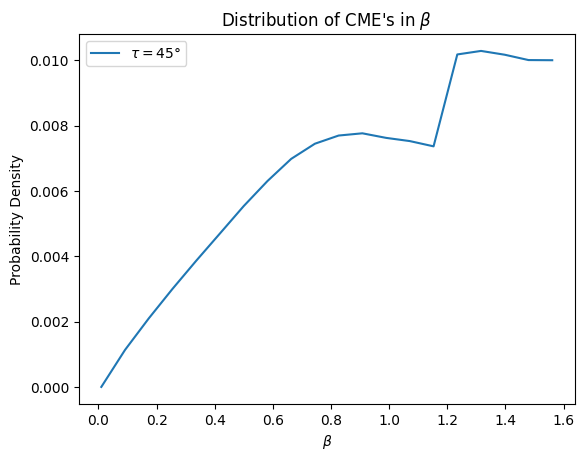

In [19]:
import time
import mcint
import random
import math
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm import tqdm
from scipy.integrate import nquad

# Define the sampler
def sampler():
    while True:
        theta = random.uniform(0, np.pi)
        phi = random.uniform(0, 2 * np.pi)
        theta2 = random.uniform(0, np.pi / 2)
        yield (theta, phi, theta2)

# Define the function to compute rho for a single beta
def get_rho_beta(beta, tau, fast=True):
    try:
        if fast:
            result, error = mcint.integrate(f_integrand_(beta, tau), sampler(), measure=1, n=10000)
            print(error)
        else:
            start_time = time.time()
            print(beta, tau, end='\r')
            result, error = nquad(
                f_integrand_(beta, tau, vec=False),
                [
                    [0, np.pi],       # theta
                    [0, 2 * np.pi],   # phi
                    [0, np.pi / 2],   # theta2
                ],
                opts={'epsabs': 1e-5, 'epsrel': 1e-5}  # Adjusted tolerances for faster computation
            )
            end_time = time.time()
            print(f'For params {beta=}, {tau = } we find the distribution to be {result}, with estimated error {error}. '
                  f'Taking {(end_time - start_time):.2f} seconds to calculate.')
        return result
    except Exception as e:
        print(f"Error in get_rho_beta for beta={beta}, tau={tau}: {e}")
        return np.nan

# Parallel computation for the last 4 points using joblib with tqdm
def compute_last_points_with_joblib(betas, tau, fast=True):
    # Wrap the iterable in tqdm for progress bar
    results = Parallel(n_jobs=8)(
        delayed(get_rho_beta)(beta, tau, fast) for beta in tqdm(betas, desc="Computing Betas")
    )
    return results

# Initialize betas, tau, and existing results
betas = np.linspace(0.01, np.pi / 2 - 0.01, 20)
tau = np.linspace(0, np.pi / 2, 5)[2]
p4 = [4.909303815842216e-11, 0.00113404043786093, 0.002098566427120833, 0.003001919941460483, 0.0038636277938305, 
      0.004698260108988724, 0.00553566346811016, 0.0063011911664989685, 0.006980198499961342, 0.007444495009302519, 
      0.007694623124679994, 0.007762869602409423, 0.007623055211972881, 0.007524749736248599, 0.00736382419209615, 
      float('nan'), float('nan'), float('nan'), float('nan'), float('nan')]
#p3 = [0, 0.0003220914905380947, 0.0007462914008812184, 0.0012962789514624332, 0.0020030709886026143, 
#      0.002833559214482715, 0.0037298218518687348, 0.004605105582697563, 0.005466665617000759, 
#      0.006291952846461997, 0.00714285803278854, 0.008031565996588236, 0.008803298610613065, 
#      0.009583950012509451, 0.010059999582775422, 0.010203355244296457, np.nan, np.nan, np.nan, np.nan]


# Identify betas for the last 4 points
last_4_betas = betas[15:20]  # Select the last 4 betas to compute

# Compute the last 4 points in parallel using joblib with progress bar
try:
    last_4_results = compute_last_points_with_joblib(last_4_betas, tau, fast=False)
    # Update the results array
    p4[-5:] = last_4_results  # Corrected to update only the last 4 values
except Exception as e:
    print(f"Error during parallel computation: {e}")

# Plot the results
print(p4)
plt.plot(betas, p4, label=fr'$\tau=${round(tau * 180 / np.pi)}°')
plt.title(r"Distribution of CME's in $\beta$")
plt.xlabel(r"$\beta$")
plt.ylabel("Probability Density")
plt.legend()
plt.show()


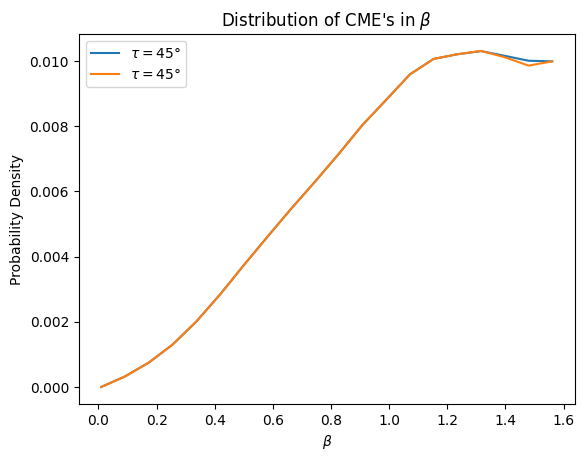

In [17]:
p32 = [0, 0.0003220914905380947, 0.0007462914008812184, 0.0012962789514624332, 0.0020030709886026143, 
      0.002833559214482715, 0.0037298218518687348, 0.004605105582697563, 0.005466665617000759, 
      0.006291952846461997, 0.00714285803278854, 0.008031565996588236, 0.008803298610613065, 
      0.009583950012509451, 0.010059999582775422, 0.010203355244296457, 0.010305779840683245, 
      0.01011177532621473, 0.009856037737994159, 0.009984232281591619]

plt.plot(betas, p3, label=fr'$\tau=${round(tau * 180 / np.pi)}°')
plt.plot(betas, p32, label=fr'$\tau=${round(tau * 180 / np.pi)}°')
plt.title(r"Distribution of CME's in $\beta$")
plt.xlabel(r"$\beta$")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

/usr/local/lib/python3.11/site-packages/scipy/integrate/_quadpack_py.py:1233: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


For params beta=0.01, tau = 1.5707963267948966 we find the distibution to be 1.2425113319263e-12, with estimated error 5.5483954820878013e-08.             Taking 336.09 to calculate.


/usr/local/lib/python3.11/site-packages/scipy/integrate/_quadpack_py.py:1233: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


For params beta=0.09162085930499456, tau = 1.5707963267948966 we find the distibution to be 0.0017521142725877188, with estimated error 1.827695413344224e-07.             Taking 43234.55 to calculate.
For params beta=0.17324171860998913, tau = 1.5707963267948966 we find the distibution to be 0.0032164255798418514, with estimated error 2.59579805834589e-08.             Taking 5699.03 to calculate.
For params beta=0.2548625779149837, tau = 1.5707963267948966 we find the distibution to be 0.004494436753791217, with estimated error 3.797830139412142e-07.             Taking 9642.66 to calculate.
For params beta=0.33648343721997825, tau = 1.5707963267948966 we find the distibution to be 0.0055103355608575435, with estimated error 1.4899379380964958e-08.             Taking 1458.85 to calculate.
For params beta=0.41810429652497283, tau = 1.5707963267948966 we find the distibution to be 0.006196952979336932, with estimated error 6.247040358494515e-08.             Taking 9701.16 to calculate.
Fo

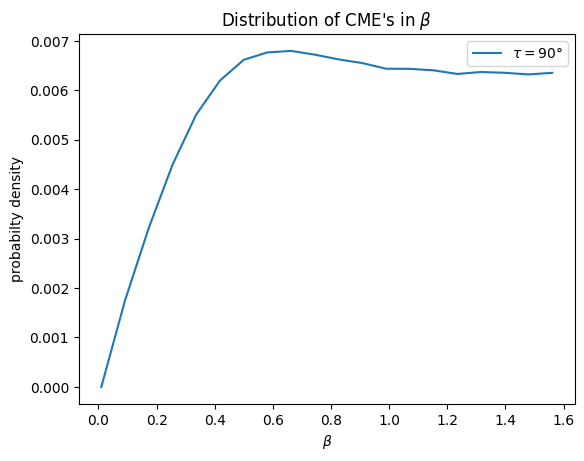

In [10]:
import time
import mcint
import random
import math

def sampler():
    while True:
        theta     = random.uniform(0, np.pi)
        phi  = random.uniform(0, 2*np.pi)
        theta2    = random.uniform(0, np.pi/2)
    
        yield (theta, phi, theta2)

def get_rho_beta(beta, tau, fast=True):
    if fast:
        result, error = mcint.integrate(f_integrand_(beta, tau), sampler(), measure=1, n=10000)
        print(error)
    else:
        start_time = time.time()
        print(beta, tau, end='\r')
        result, error = scipy.integrate.nquad(f_integrand_(beta, tau, vec=False), [[0, np.pi],       # theta, phi, theta2
                                                    [0, 2*np.pi],         # phi
                                                    [0, np.pi / 2 ]])        # theta2
        end_time = time.time()
        print(f'For params {beta=}, {tau = } we find the distibution to be {result}, with estimated error {error}. \
            Taking {(end_time-start_time):.2f} to calculate.')

    return result


def rho_betas(betas, tau, fast=True):
    return [get_rho_beta(beta, tau, fast) for beta in betas]

betas = np.linspace(0.01,np.pi/2-0.01, 20)

tau = np.linspace(0,np.pi/2, 5)[4]


a = rho_betas(betas, tau, fast)
plt.plot(betas, a, label=fr'$\tau=${round(tau*180/np.pi)}°')
print(betas, a)

# plt.ylim(0,5)
plt.title(r"Distribution of CME's in $\beta$")
plt.xlabel(r"$\beta$")
plt.ylabel("probabilty density")
plt.legend()

In [13]:
import time
import mcint
import random
import math
import numpy as np
import matplotlib.pyplot as plt
import concurrent.futures

# Define the sampler
def sampler():
    while True:
        theta = random.uniform(0, np.pi)
        phi = random.uniform(0, 2 * np.pi)
        theta2 = random.uniform(0, np.pi / 2)
        yield (theta, phi, theta2)

# Function to calculate rho for a single beta
def calculate_rho_beta(args):
    beta, tau, fast = args
    return get_rho_beta(beta, tau, fast)

# Define the main computation function
def get_rho_beta(beta, tau, fast=True):
    if fast:
        result, error = mcint.integrate(f_integrand_(beta, tau), sampler(), measure=1, n=10000)
        print(error)
    else:
        start_time = time.time()
        print(beta, tau, end='\r')
        result, error = scipy.integrate.nquad(
            f_integrand_(beta, tau, vec=False),
            [
                [0, np.pi],       # theta
                [0, 2 * np.pi],   # phi
                [0, np.pi / 2],   # theta2
            ]
        )
        end_time = time.time()
        print(f'For params beta= {beta:.3f}, tau= {tau:.3f} we find the distribution to be {result:.6f}, with estimated error {error:.6e}. '
              f'Taking {(end_time - start_time):.2f} seconds to calculate.')
    return result

# Function for parallel computation of rho_betas
def rho_betas_parallel(betas, tau, fast=True):
    with concurrent.futures.ProcessPoolExecutor(max_workers=8) as executor:
        # Pass arguments as tuples to avoid lambdas
        results = list(executor.map(calculate_rho_beta, [(beta, tau, fast) for beta in betas]))
    return results

# Define the range of betas and tau
betas = np.linspace(0, np.pi / 2, 20)
tau = np.linspace(0, np.pi / 2, 5)[2]

# Compute the next 10 betas (indices 10 to 19) in parallel
betas_to_compute = betas[10:20]
results = rho_betas_parallel(betas_to_compute, tau, fast=False)

# Combine the results with previously computed results
previous_results = np.array([
    np.nan,  # For beta=0.0
    0.0003220914905380947,
    0.0007462914008812184,
    0.0012962789514624332,
    0.0020030709886026143,
    0.002833559214482715,
    0.0037298218518687348,
    0.004605105582697563,
    0.005466665617000759,
    0.006291952846461997,
])
all_results = np.concatenate((previous_results, results))

# Plot the results
plt.plot(betas, all_results, label=fr'$\tau=${round(tau * 180 / np.pi)}°')
plt.title(r"Distribution of CME's in $\beta$")
plt.xlabel(r"$\beta$")
plt.ylabel("Probability Density")
plt.legend()
plt.show()


Python(72112) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(72113) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(72115) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(72116) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(72117) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(72118) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(72119) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(72120) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Process SpawnProcess-24:
Traceback (most recent call last):
Process SpawnProcess-18:
Traceback (most recent call last):
  File "/usr/local/Cellar/python@3.11/3.11.4_1/Frameworks/Python.framework/Versions/3.11/lib/pyt

BrokenProcessPool: A process in the process pool was terminated abruptly while the future was running or pending.

In [15]:
!export MallocStackLoggingNoCompact=1

Python(72136) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


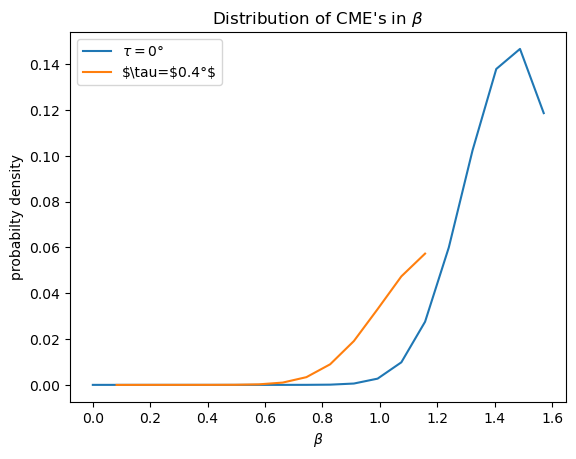

In [28]:
# partial results after 40 min of fast=False integration

b = np.array([0.         , 0.08267349 , 0.16534698 , 0.24802047, 0.33069396 , 0.41336745, 0.49604095 , 0.57871444 , 0.66138793 , 0.74406142, 0.82673491, 0.9094084, 0.99208189 , 1.07475538 , 1.15742887 , 1.24010236 , 1.32277585 , 1.40544935, 1.48812284 , 1.57079633])
p1=np.array([-1.244302803098822e-07, -2.020597301041954e-08, -2.9419197471627263e-09, -3.8506323427838335e-10, -3.9187265313228005e-11, 1.9396522511149444e-10, 4.663246386506073e-09, 8.342455036253888e-08, 1.1389400438405107e-06, 1.1879469422441976e-05, 9.478730484257619e-05, 0.0005795594748075021, 0.0027215705946284224, 0.009845515893399727, 0.027552861542427205, 0.059989051795611634, 0.10235890555562867, 0.13789471596377173, 0.1466504419075839, 0.11862377157730396])

b2 = [0.08267349088394192, 0.16534698176788384, 0.24802047265182575, 0.3306939635357677, 0.4133674544197096, 0.4960409453036515, 0.5787144361875934, 0.6613879270715354, 0.7440614179554773, 0.8267349088394192, 0.9094083997233612, 0.992081890607303,  1.074755381491245,  1.1574288723751869]
p2 = [ -2.22823150296887e-05, -5.713519770368957e-06, -1.3154789700561033e-06 -2.291901862322346e-07, 5.214006036830509e-07,  5.532554756659216e-06,  4.068847682634011e-05,  0.00022888900934754633,  0.0009946273992843017, 0.0033683418491653166, 0.008984065218520531, 0.019127553436737478,0.033065651186741915, 0.047353504995598206,  0.05729989712276298]


plt.plot(b, p1, label=fr'$\tau=$0°')
plt.plot(b2, p2, label=fr'$\tau=$0.4°$')

# plt.ylim(0,5)
plt.title(r"Distribution of CME's in $\beta$")
plt.xlabel(r"$\beta$")
plt.ylabel("probabilty density")
plt.legend()

<!-- # Other distributions:
## Normal around the equatator -->